In [4]:
import time

import numpy as np
import matplotlib.pyplot as plt

from firm3d.field.boozermagneticfield import (
    BoozerRadialInterpolant,
    InterpolatedBoozerField,
)
from firm3d.field.trajectory_helpers import TrappedPoincare
from firm3d.util.constants import (
    ALPHA_PARTICLE_CHARGE,
    ALPHA_PARTICLE_MASS,
    FUSION_ALPHA_PARTICLE_ENERGY,
)
from firm3d.util.functions import proc0_print, setup_logging
from firm3d.util.mpi import comm_size, comm_world, verbose

# Can comment out these inputs below if call_DESC==False
from desc.ResonanceOpt.TRObj_func import TrappedResonanceObj
import desc.io
from desc.backend import set_device
set_device("cpu")
import jax.numpy as jnp

In [6]:
#######################
# COMMON USER INPUTS #
# firm3d setup
boozmn_filename = "../inputs/boozmn_equil_Helios_E0092_DESC_fixed.nc" # make sure this matches the DESC input
neta_poinc = 10  # Number of eta initial conditions for poincare
ns_poinc = 15  # Number of s initial conditions for poincare
Nmaps = 1000  # Number of Poincare return maps to compute
modBin = 6.55 # T
tmax = 1e-2

# DESC setup
eq = desc.io.load("../inputs/equil_Helios_E0092_DESC_fixed.h5") # make sure this matches the firm3d input
rhos_desc = (np.linspace(0.1,0.9,50))**(1/2) # rho = sqrt(s)
alphas_desc = np.linspace(0,2*np.pi,3)
KE_frac_desc = np.array([1]) #did 0.001 before
N=0 # QA
#######################

In [7]:
# Additional setup

Ekin = FUSION_ALPHA_PARTICLE_ENERGY * KE_frac_desc[0]
charge = ALPHA_PARTICLE_CHARGE
mass = ALPHA_PARTICLE_MASS

resolution = 48  # Resolution for field interpolation
ns_interp = resolution  # number of radial grid points for interpolation
ntheta_interp = resolution  # number of poloidal grid points for interpolation
nzeta_interp = resolution  # number of toroidal grid points for interpolation
order = 3  # order for interpolation
tol = 1e-8  # Tolerance for ODE solver
s_mirror = 0.5  # flux surface for mirroring
theta_mirror = np.pi / 2  # poloidal angle for mirroring
zeta_mirror = 0
helicity_M = 1  # helicity of field strength contours
helicity_N = N # =0 for QA
degree = 3  # Degree for Lagrange interpolation


# Setup logging to redirect output to file
#setup_logging(f"stdout_trapped_map_{resolution}_{comm_size}.txt")

In [8]:
# Trapped map particle tracing
time1 = time.time()

bri = BoozerRadialInterpolant(boozmn_filename, order, no_K=True, comm=comm_world)

field = InterpolatedBoozerField(
    bri,
    degree,
    ns_interp=ns_interp,
    ntheta_interp=ntheta_interp,
    nzeta_interp=nzeta_interp,
)

poinc = TrappedPoincare(
    field,
    helicity_M,
    helicity_N,
    s_mirror,
    theta_mirror,
    zeta_mirror,
    mass,
    charge,
    Ekin,
    modBin=modBin,
    ns_poinc=ns_poinc,
    neta_poinc=neta_poinc,
    Nmaps=Nmaps,
    comm=comm_world,
    solver_options={"reltol": tol, "abstol": tol, "axis": 0},
    tmax=tmax,
)

time2 = time.time()
proc0_print("poincare time: ", time2 - time1)

poincare time:  181.2705192565918


NameError: name 'ax' is not defined

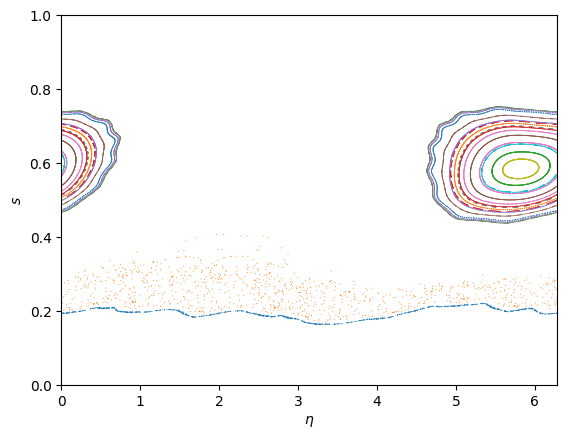

In [9]:
# Poincare plotting
fig, ax = plt.subplots()
ax = poinc.plot_poincare(ax=ax)

In [10]:
# Run DESC objective function
pitch_invs_desc = jnp.array([modBin])
out = TrappedResonanceObj(eq,rhos_desc,pitch_invs_desc,KE_frac_desc,alphas_desc,N)
obj_val = out['obj'][:,0,0] # Only look at rho, for one pitch, for one energy
s_obj = np.linspace(0.1,0.9,len(obj_val))

Precomputing transforms


In [17]:
# Plotting the objective function over the Poincare plot
Y = s_obj
X = np.linspace(0,2*np.pi,5)
Z = np.transpose(np.tile(obj_val, (5, 1)))
cs = ax.contourf(X,Y,Z,cmap='Blues')
fig.colorbar(cs, ax=ax)

ax = poinc.plot_poincare(ax=ax)
ax.figure.savefig('poincare_objective_overlay.png')

In [23]:
# Saving Poincare plot for testing
import pickle
fig,ax = plt.subplots()
ax = poinc.plot_poincare(ax=ax)
pickle.dump(fig, open("testing.pkl", "wb"))

In [27]:
# Run after kernel restart to get Poincare plot back
fig = pickle.load(open("testing.pkl", "rb"))
fig.savefig('testing.png')

In [19]:
# Objective function testing
print(out['psi_da'])

[[[ 413.49795378]]

 [[ 181.32256873]]

 [[ 134.58864352]]

 [[  38.63737352]]

 [[ -29.45124193]]

 [[ 135.11967297]]

 [[ 200.24183777]]

 [[ 234.12409316]]

 [[ 117.12061301]]

 [[ -38.55301405]]

 [[  89.34966687]]

 [[ 280.03865486]]

 [[ 265.76954772]]

 [[ 136.14338705]]

 [[  11.96854937]]

 [[ -28.24255305]]

 [[  11.11851929]]

 [[  65.76060026]]

 [[  90.30673386]]

 [[  70.16269517]]

 [[  13.2115858 ]]

 [[ -70.73961311]]

 [[-171.21937491]]

 [[-281.07574961]]

 [[-394.24448907]]

 [[-504.9796598 ]]

 [[-608.27922992]]

 [[-698.91846744]]

 [[-770.41134325]]

 [[-816.73933855]]

 [[-831.72838097]]

 [[-809.02199586]]

 [[-741.03449161]]

 [[-621.01099776]]

 [[-443.52617365]]

 [[-204.78108409]]

 [[  97.38739835]]

 [[ 465.66408888]]

 [[ 897.81718253]]

 [[1386.17883114]]

 [[1920.81271361]]

 [[2480.9785023 ]]

 [[3032.5098534 ]]

 [[3522.69896739]]

 [[3874.34937376]]

 [[3995.54162068]]

 [[3818.37201409]]

 [[3414.44471091]]

 [[3053.25860518]]

 [[3021.06623808]]]
